In [105]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [106]:
df = pd.read_csv('student_exam_performance_dataset.csv')


In [107]:
df.head()

,student_id,gender,age,parental_education,family_income,internet_access,study_environment,study_hours_per_day,attendance_rate,sleep_hours,...,online_courses_completed,tutoring,math_score,reading_score,writing_score,science_score,final_exam_score,previous_gpa,pass_fail,grade_category
0,S00001,Male,17,High School,Medium,Yes,Quiet,2.98,96.5,6.05,...,1,Yes,42.8,62.4,54.8,51.8,49.1,2.44,Fail,F
1,S00002,Female,18,High School,Low,Yes,Quiet,4.45,95.7,6.96,...,0,Yes,77.9,73.5,64.4,61.6,70.1,2.79,Pass,C
2,S00003,Male,17,High School,Medium,No,Quiet,3.75,76.0,7.02,...,4,Yes,53.5,38.3,36.3,47.1,42.2,1.49,Fail,F
3,S00004,Male,18,Bachelor,Medium,Yes,Quiet,2.03,72.6,6.23,...,4,No,28.3,23.5,32.0,39.0,31.9,1.34,Fail,F
4,S00005,Male,18,Bachelor,Medium,Yes,Quiet,5.14,87.3,8.54,...,0,No,74.7,54.9,73.6,55.5,66.4,2.60,Pass,C


In [108]:
# df.columns

In [109]:
columns_drop = ['student_id','gender','family_income','age','math_score','reading_score','writing_score','science_score','final_exam_score','grade_category','previous_gpa']
df.drop(columns_drop, inplace=True, axis=1)

In [110]:
# df.head()

In [111]:
# study_hours = df['study_hours_per_day']
# passed = df['pass_fail']


In [112]:
# df.drop(['parental_education'],inplace=True, axis=1)

In [113]:
# df.head()

In [114]:
X = df.drop('pass_fail', axis=1)
y = df['pass_fail']

In [115]:
X = pd.get_dummies(X, drop_first=True)

In [116]:
X.head()

,study_hours_per_day,attendance_rate,sleep_hours,social_media_hours,assignment_completion_rate,participation_score,online_courses_completed,parental_education_High School,parental_education_Master,parental_education_PhD,internet_access_Yes,study_environment_Noisy,study_environment_Quiet,tutoring_Yes
0,2.98,96.5,6.05,0.1,80.5,68.7,1,True,False,False,True,False,True,True
1,4.45,95.7,6.96,2.9,70.9,92.6,0,True,False,False,True,False,True,True
2,3.75,76.0,7.02,2.4,77.6,45.8,4,True,False,False,False,False,True,True
3,2.03,72.6,6.23,3.5,63.5,72.9,4,False,False,False,True,False,True,False
4,5.14,87.3,8.54,2.1,71.8,55.7,0,False,False,False,True,False,True,False


In [117]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(y)

In [118]:
#Now lets train the model of logistic regression
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [119]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train,y_train)

c:\Users\akula\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [120]:
y_preds = model.predict(X_test)

Classification Report :                precision    recall  f1-score   support

           0       0.75      0.75      0.75      1070
           1       0.71      0.70      0.71       930

    accuracy                           0.73      2000
   macro avg       0.73      0.73      0.73      2000
weighted avg       0.73      0.73      0.73      2000

Accuracy Score :  0.7305


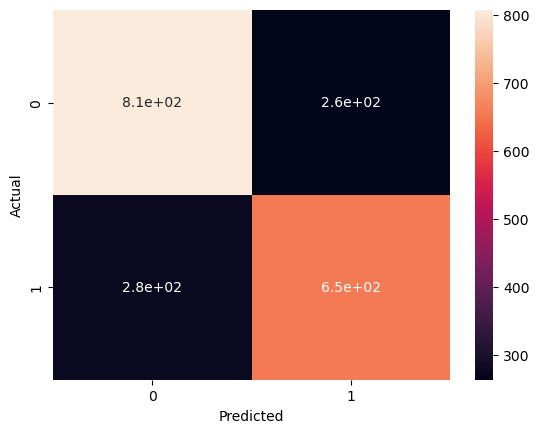

In [121]:
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score
score = accuracy_score(y_test,y_preds)
cm = confusion_matrix(y_test,y_preds)
sns.heatmap(cm,annot=True)
plt.xlabel("Predicted")
plt.ylabel("Actual")
print("Classification Report : ",classification_report(y_test,y_preds))
print("Accuracy Score : ",score)